In [ ]:
#import the depndencies


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

import matplotlib.pyplot as plt


In [4]:
import pandas as pd

data = pd.read_csv(
    r"C:\\Users\\pranitha\\Desktop\\ASSIGNMENTS\\Elevate labs\\task8\\bank-full.csv",
    sep=';'  # important for UCI file
)

display(data.head())
data.info()
print(data['y'].value_counts())


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
y
no     39922
yes     5289
Name: count, dtype: int64


In [ ]:
# Basic cleaning

In [5]:
cat_cols = data.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')

for col in cat_cols:
    data[col] = data[col].str.lower().str.strip()

data[cat_cols] = data[cat_cols].replace('unknown', np.nan)


In [6]:
data[cat_cols] = data[cat_cols].fillna('unknown')


In [7]:
# split the data into feature and target variables

X = data.drop('y', axis=1)
y = data['y'].map({'no': 0, 'yes': 1})  # binary target


In [8]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)


In [9]:
# Train–test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [11]:
# Train decision tree and visualize

In [ ]:
# Model with max_depth

In [12]:
dt_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,          # tune later
    min_samples_split=50, # simple regularization
    random_state=42
)

clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', dt_clf)
])

clf.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Train vs test accuracy

In [13]:
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)
print(classification_report(y_test, y_test_pred))


Train accuracy: 0.902621101526211
Test accuracy: 0.8998120092889528
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7985
           1       0.65      0.31      0.42      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043



In [ ]:
#  Visualize tree

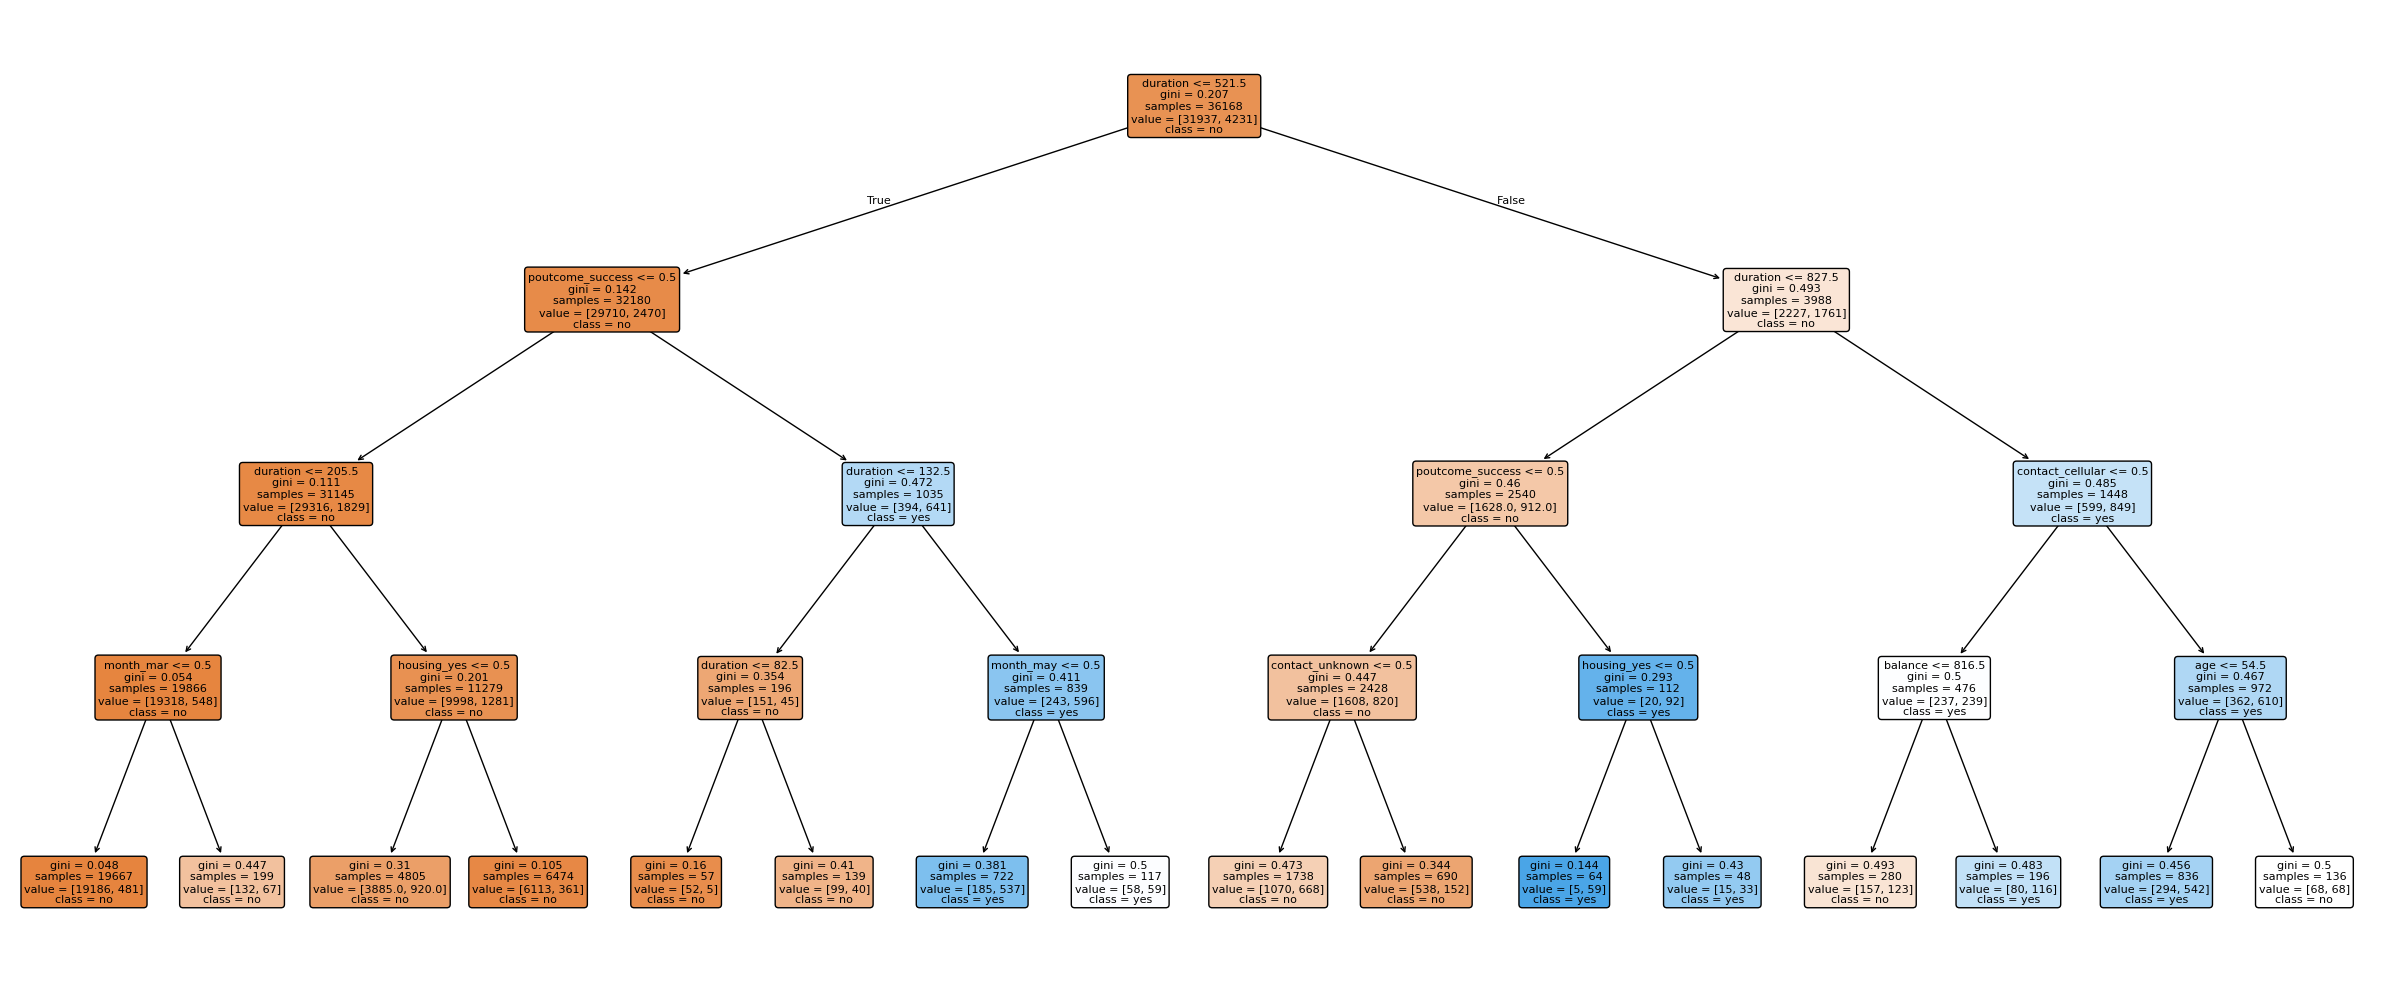

In [15]:
# Get feature names AFTER clf.fit(...)
ohe = clf.named_steps['preprocess'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(cat_cols)
feature_names = np.concatenate([ohe_features, num_cols])

# 2. Extract the trained tree model from the pipeline
dt_model = clf.named_steps['model']

# 3. Plot and save the tree
import os
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(24, 10))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=['no', 'yes'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.tight_layout()
plt.savefig("images/tree_bank_marketing.png", dpi=300)
plt.show()
